In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, RANSACRegressor
from sklearn.metrics import mean_squared_error


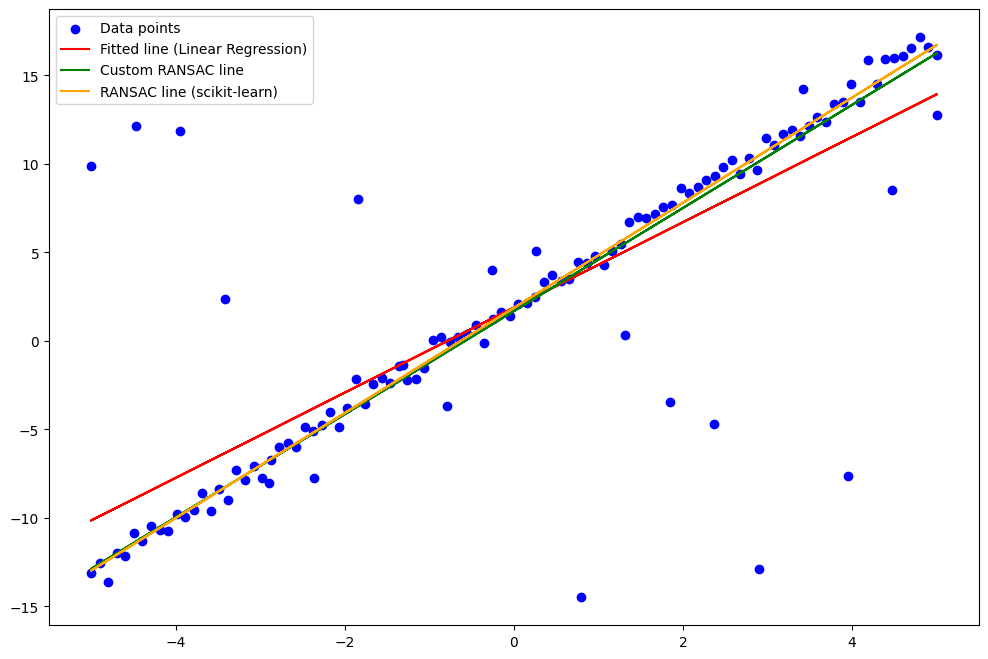

Standard Linear Regression MSE: 27.25122412376751
Custom RANSAC MSE: 29.49376340923741
Scikit-learn RANSAC MSE: 29.971744446242624


In [8]:
# Generating 100 inliers
X_inliers = np.linspace(-5, 5, 100)
y_inliers = 3 * X_inliers + 2 + np.random.normal(0, 0.5, 100)

# Generating 20 outliers
X_outliers = np.linspace(-5, 5, 20)
y_outliers = 30 * (np.random.random(20) - 0.5)

# Concatenating inliers and outliers into one dataset
X = np.concatenate((X_inliers, X_outliers))
y = np.concatenate((y_inliers, y_outliers))

# Reshape X for model fitting
X = X.reshape(-1, 1)

# Model Fitting using all data (Linear Regression)
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# RANSAC (custom implementation)
n_iterations = 100
n_samples = X.shape[0]
sample_size = int(n_samples * 0.6)
t = 0.1
best_model = None
best_inlier_num = 0

for _ in range(n_iterations):
    # select random samples
    sample = np.random.choice(n_samples, sample_size)
    X_sample = X[sample]
    y_sample = y[sample]

    # fit model to the samples
    model_sample = LinearRegression().fit(X_sample, y_sample)
    y_sample_pred = model_sample.predict(X)

    # find inliers
    residuals = np.abs(y_sample_pred - y)
    inliers = residuals < t
    inlier_num = np.count_nonzero(inliers)

    # update the best model if the current one is better
    if inlier_num > best_inlier_num:
        best_inlier_num = inlier_num
        best_model = model_sample

# Predict using the custom RANSAC model
y_pred_custom_ransac = best_model.predict(X)

# RANSAC (scikit-learn implementation)
ransac = RANSACRegressor()
ransac.fit(X, y)
y_pred_sklearn_ransac = ransac.predict(X)

# Plotting all results
plt.figure(figsize=(12, 8))
plt.scatter(X, y, color='blue', label='Data points')

# Plotting the standard linear regression result
plt.plot(X, y_pred, color='red', label='Fitted line (Linear Regression)')

# Plotting the custom RANSAC result
plt.plot(X, y_pred_custom_ransac, color='green', label='Custom RANSAC line')

# Plotting the sklearn RANSAC result
plt.plot(X, y_pred_sklearn_ransac, color='orange', label='RANSAC line (scikit-learn)')

plt.legend()
plt.show()

# Printing results
print("Standard Linear Regression MSE:", mean_squared_error(y, y_pred))
print("Custom RANSAC MSE:", mean_squared_error(y, y_pred_custom_ransac))
print("Scikit-learn RANSAC MSE:", mean_squared_error(y, y_pred_sklearn_ransac))


Regresja liniowa:
Regresja liniowa jest podatna na punkty bardzo odstające, co prowadzi do większych błędów (MSE) i zniekształcenia dopasowanej linii. Brak odporności na odchylenia sprawia, że model nie oddaje dobrze głównego trendu danych w obecności odchyłów.

Podana implementacja RANSAC:
Ignoruje odchyły, co prowadzi do lepszego dopasowania, jednak stabilność wyników zależy od wylosowanych punktów. W tym przypadku linia niewiele odbiega od tej bibltiotecznej, jednak przy innym rozkładzie puntków może być bardziej odchylona.

RANSAC z scikit-learn:
RANSAC z scikit-learn za każdym razem radzi sobie najlepiej z dopasowaniemi lini trendu, oznacza to tyle, że algorytm z biblioteki jest znaczni
e lepiej zoptymalizowany niż ten testowany.